<a href="https://colab.research.google.com/github/simasaadi/toronto-water-analytics/blob/main/05_in_depth_water_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In-Depth Water-Quality Analysis – Toronto AOC1 (Great Lakes DataStream)

This notebook is an in-depth analytical walkthrough of long-term water-quality data for Toronto’s AOC1 (Area of Concern), using the cleaned dataset prepared earlier in this project and stored in this repository. It is designed to look like a real analyst’s workflow that a hiring manager or technical reviewer can follow end-to-end.

The focus is on:

Understanding temporal patterns (seasonality and long-term trends)

Exploring relationships between key parameters

Identifying potential anomalies in the time series

Summarising site-level behaviour

Building spatial visualisations (interactive maps) that highlight hotspots and station behaviour

All code is written in Python and is compatible with Google Colab.

1. Data loading and preparation

What happens in the first code cell:

The notebook loads the cleaned dataset directly from GitHub as a compressed ZIP file (toronto_aoc1_clean.zip) using pandas.read_csv(..., compression="zip").

A small helper function get_col(df, fragment) is defined to find columns case-insensitively by name fragment (e.g., "ActivityStartDate", "ResultValue", "MonitoringLocationLatitude").
This makes the notebook robust to slightly different column names.

Key columns are identified:

Sampling date and time

Parameter / characteristic name

Numeric result value

Monitoring location ID

Latitude and longitude

A single activity_datetime column is built by combining the date and time fields.
From this, the notebook derives:

year

month (number)

month_name (January, February, …)

The measurement field (ResultValue) is coerced to numeric and rows without a valid timestamp or value are dropped.

A quick summary is printed:

Overall date range of the dataset

Number of unique monitoring locations

Number of distinct parameters

A small table of the top 20 most frequently measured parameters

This sets up a clean, tidy dataset (df) that all subsequent analyses use.

2. Seasonal behaviour of key parameters

To understand how water-quality varies across the year, the notebook:

Focuses on a set of key parameters, for example:

Chloride

Dissolved oxygen (DO)

Kjeldahl nitrogen

Specific conductance

Temperature, water

Filters the main dataframe to just these parameters.

Builds monthly boxplots for each parameter, with:

month_name on the x-axis (ordered January → December)

Measurement values on the y-axis

One subplot per parameter

These plots show:

Typical central values per month (median)

Spread and variability

The presence of seasonal patterns (e.g., conductivity higher in winter, DO lower in summer)

Outliers that might warrant further investigation

3. Relationships between parameters (correlation)

To examine how parameters move together, the notebook:

Aggregates the filtered dataset to daily mean values for each parameter.

Pivots to a “wide” format where each column is one parameter and each row is a date.

Computes a correlation matrix between parameters.

Visualises this matrix as a heatmap using seaborn.heatmap with:

Values from -1 to 1

Annotated correlation coefficients

A diverging colour scale

This view is useful for:

Seeing whether parameters tend to increase or decrease together

Highlighting possible redundancy or strong coupling between parameters

Giving context for multivariate analyses or future modelling

4. Anomaly detection in time series (rolling z-scores)

For a selected parameter (by default Specific conductance, but this can be changed in one variable):

The notebook aggregates measurements to monthly means.

It calculates a rolling 12-month mean and standard deviation.


Months where |z| ≥ 3 are flagged as potential anomalies.

A table of these anomalous months is displayed.

A line plot is generated showing:

Monthly mean values

The 12-month rolling mean

Red markers highlighting anomaly months

This section is framed as a way to detect:

Unusual spikes or drops that may correspond to events, data issues, or changes in operations.

5. Long-term trends and seasonal decomposition

For the same key parameter:

Seasonal decomposition

Monthly mean values are fed into statsmodels’ seasonal_decompose with:

model="additive"

period=12 (monthly data)

The algorithm splits the time series into:

Observed time series

Trend component (long-term change)

Seasonal component (recurring yearly cycle)

Residual (unexplained noise)

A four-panel plot shows each component, helping separate:

Long-term behaviour

Stability and shape of seasonality

Noise or event-driven fluctuations

Linear trend regression

The notebook also aggregates to yearly mean values for the parameter.


It reports:

Slope per year

Slope per decade

R-squared value

A scatter plot of yearly means is overlaid with the fitted trend line.

This gives a concise, quantitative statement such as:

“Specific conductance is increasing/decreasing by X units per decade, with R² = Y.”

6. Location-level summaries (non-map spatial view)

To summarise spatial behaviour:

The dataset is filtered to a single parameter (again, default is Specific conductance).

The notebook groups by monitoring location ID, computing:

mean_val – mean measurement across the whole record

median_val – median value

n_samples – number of samples at that site

lat, lon – first recorded latitude/longitude for the station

It then builds an interactive scatter plot (Plotly) with:

Longitude on the x-axis, latitude on the y-axis

Colour = mean value

Marker size = number of samples

Hover tooltip with ID, mean, median, and sample count

This acts as a bridge between pure time-series analysis and the more detailed maps that follow.

7. Interactive maps (Folium)

The notebook includes three different map views, all focused on a single parameter (e.g., Specific conductance). These maps reuse the site_summary table described above and the raw measurements for that parameter.

Map 1 – Station markers sized by sampling effort

Base map centred on Toronto using Folium.

Each monitoring location is drawn as a circle marker:

Radius proportional to the number of samples at that site

Popup showing site ID, mean value, median value, and sample count

Purpose: quickly show which stations are heavily monitored vs. sparsely sampled.

Map 2 – Stations coloured by mean value (with legend)

Uses the same station summary but encodes mean parameter value as colour.

A continuous YlOrRd colour scale (yellow → red) is created via branca.colormap.linear.YlOrRd_09.

Each location is drawn as a circle with:

Fixed radius

Fill colour determined by the site’s mean value

Popup with mean, median, and sample count

A colour legend is added to the map so values are interpretable.

Purpose: visual spatial gradient of parameter levels across stations.

Map 3 – Heatmap of parameter intensity / hotspots

The dataset is again filtered to the chosen parameter, keeping only rows with valid lat/lon and numeric values.

To prevent extreme outliers from dominating the picture:

Values are clipped at the 95th percentile

Then normalised to 0–1 as weights

The HeatMap plugin from folium.plugins is used to draw a kernel-density-style heatmap over Toronto:

Each measurement contributes a “hot spot” whose intensity is proportional to its weight.

A dark base map is used so hot areas stand out clearly.

Purpose: highlight where high concentrations and/or high values are clustered, rather than just point-wise information.

In [5]:
import pandas as pd

# ------------------------------------------------------------
# 1. Load the cleaned ZIP directly from your GitHub repository
# ------------------------------------------------------------

zip_url = "https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/main/data/cleaned/toronto_aoc1_clean.zip"

print("Loading data from:", zip_url)
df = pd.read_csv(zip_url, compression="zip", low_memory=False)
print("Rows loaded:", len(df))
print("First columns:", list(df.columns)[:20])

# ------------------------------------------------------------
# 2. Helper to find columns case-insensitively
# ------------------------------------------------------------

def get_col(df, target):
    target = target.lower()
    for c in df.columns:
        if c.lower() == target:
            return c
    raise KeyError(f"Column matching '{target}' not found. Available: {list(df.columns)[:20]}")

# ------------------------------------------------------------
# 3. Basic cleaning (activity datetime, year/month/result value)
# ------------------------------------------------------------

date_col = get_col(df, "ActivityStartDate")
time_col = get_col(df, "ActivityStartTime")
loc_col = get_col(df, "MonitoringLocationID")
char_col = get_col(df, "CharacteristicName")
value_col = get_col(df, "ResultValue")

# Convert date
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Combine date + time
df[time_col] = df[time_col].fillna("00:00:00")
dt_str = df[date_col].dt.strftime("%Y-%m-%d") + " " + df[time_col].astype(str)
df["activity_datetime"] = pd.to_datetime(dt_str, errors="coerce")

# Derive year and month
df["year"] = df["activity_datetime"].dt.year
df["month"] = df["activity_datetime"].dt.month
df["month_name"] = df["activity_datetime"].dt.month_name()

# Ensure result values are numeric
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

# ------------------------------------------------------------
# 4. Basic summary printout
# ------------------------------------------------------------

print("\nDate range:", df["activity_datetime"].min(), "→", df["activity_datetime"].max())
print("Unique monitoring locations:", df[loc_col].nunique())
print("Unique parameters:", df[char_col].nunique())

param_counts = (
    df[char_col]
    .value_counts()
    .head(20)
    .rename_axis("CharacteristicName")
    .reset_index(name="n_records")
)

param_counts


Loading data from: https://raw.githubusercontent.com/simasaadi/toronto-water-analytics/main/data/cleaned/toronto_aoc1_clean.zip
Rows loaded: 770611
First columns: ['id', 'doi', 'datasetname', 'monitoringlocationid', 'monitoringlocationname', 'monitoringlocationlatitude', 'monitoringlocationlongitude', 'monitoringlocationhorizontalcoordinatereferencesystem', 'monitoringlocationtype', 'activitytype', 'activitymedianame', 'activitystartdate', 'activitystarttime', 'samplecollectionequipmentname', 'characteristicname', 'resultvalue', 'resultunit', 'resultvaluetype', 'activity_datetime', 'year']

Date range: 1964-10-01 03:02:00 → 2024-01-22 09:18:57
Unique monitoring locations: 623
Unique parameters: 104


,CharacteristicName,n_records
0,"Total Phosphorus, mixed forms",34537
1,Specific conductance,34337
2,Chloride,30382
3,"Temperature, water",28989
4,Kjeldahl nitrogen,28531
5,Dissolved oxygen (DO),28265
6,Nitrite,26159
7,Orthophosphate,25211
8,Total suspended solids,24236
9,"Alkalinity, total",24096


Parameters found in data: ['Chloride', 'Dissolved oxygen (DO)', 'Kjeldahl nitrogen', 'Specific conductance', 'Temperature, water']
Shape of daily parameter table: (6413, 5)


characteristicname,Chloride,Dissolved oxygen (DO),Kjeldahl nitrogen,Specific conductance,"Temperature, water"
characteristicname,,,,,
Chloride,1.000000,0.042196,-0.000967,0.215078,-0.028465
Dissolved oxygen (DO),0.042196,1.000000,-0.060060,0.284254,-0.334765
Kjeldahl nitrogen,-0.000967,-0.060060,1.000000,0.041263,-0.033848
Specific conductance,0.215078,0.284254,0.041263,1.000000,-0.240550
"Temperature, water",-0.028465,-0.334765,-0.033848,-0.240550,1.000000


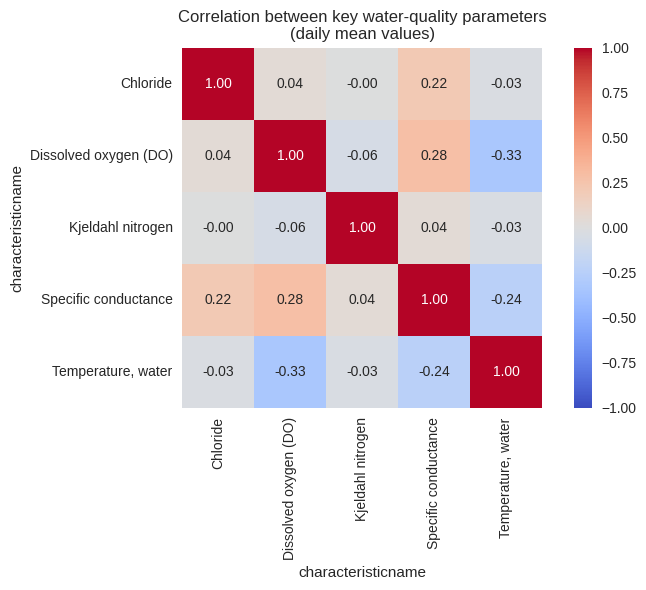

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 2. Correlation between key water-quality parameters
# ------------------------------------------------------------

# Use the same parameters as in your dashboard
candidate_params = [
    "Chloride",
    "Dissolved oxygen (DO)",
    "Kjeldahl nitrogen",
    "Specific conductance",
    "Temperature, water",
]

# Make sure we only keep parameters that actually exist in the data
available_params = sorted(
    set(candidate_params).intersection(set(df[char_col].unique()))
)

print("Parameters found in data:", available_params)

# Filter to those parameters
df_params = df[df[char_col].isin(available_params)].copy()

# Aggregate to daily mean for each parameter
daily_param = (
    df_params
    .groupby([date_col, char_col])[value_col]
    .mean()
    .unstack(char_col)
)

print("Shape of daily parameter table:", daily_param.shape)

# Compute correlation matrix
corr = daily_param.corr()
display(corr)

# ------------------------------------------------------------
# 3. Plot correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Correlation between key water-quality parameters\n(daily mean values)")
plt.tight_layout()
plt.show()


Parameter for anomaly detection: Specific conductance
Number of monthly points: 680

Detected anomalies (|z| >= 3):


,value,rolling_mean,z_score
month_date,,,
1976-01-01,1991.739130,742.242114,3.117218
2003-02-01,7825.000000,1548.681505,3.146852
2005-12-01,2505.000000,1033.581491,3.049112
2016-02-01,7453.918919,1956.645787,3.002756


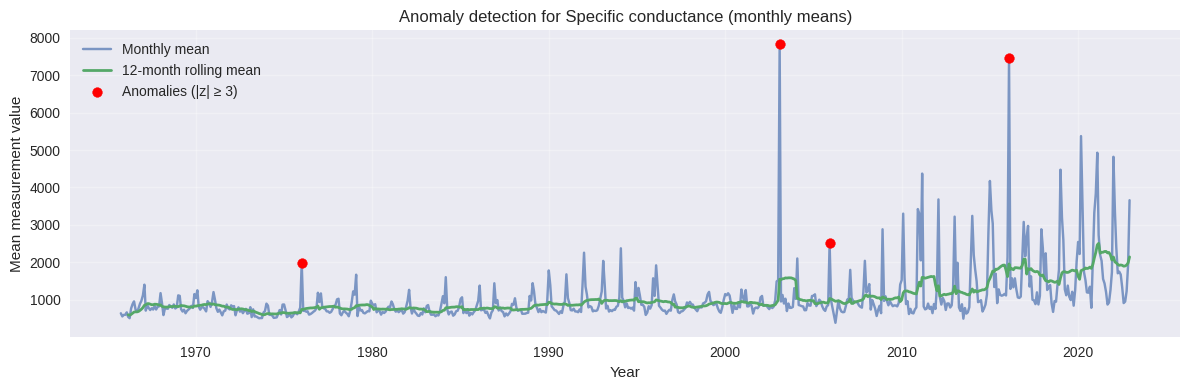

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Anomaly detection on monthly trends (rolling z-scores)
# ------------------------------------------------------------

# 1. Choose a parameter to analyze
param_for_anomaly = "Specific conductance"   # change to another if you like

print("Parameter for anomaly detection:", param_for_anomaly)

# Filter to that parameter and keep valid datetimes
df_param = df[df[char_col] == param_for_anomaly].copy()
df_param = df_param.dropna(subset=["activity_datetime"])

# 2. Aggregate to monthly mean across all sites
df_param["month_date"] = df_param["activity_datetime"].dt.to_period("M").dt.to_timestamp()

monthly_ts = (
    df_param
    .groupby("month_date")[value_col]
    .mean()
    .sort_index()
)

print("Number of monthly points:", len(monthly_ts))

# 3. Compute rolling 12-month mean and std, then z-scores
rolling_window = 12  # 12 months

rolling_mean = monthly_ts.rolling(window=rolling_window, min_periods=6).mean()
rolling_std = monthly_ts.rolling(window=rolling_window, min_periods=6).std()

z_scores = (monthly_ts - rolling_mean) / rolling_std

# Define anomalies as |z| >= 3
anomaly_mask = z_scores.abs() >= 3
anomalies = monthly_ts[anomaly_mask]

print("\nDetected anomalies (|z| >= 3):")
anomaly_table = (
    pd.DataFrame({
        "value": monthly_ts,
        "rolling_mean": rolling_mean,
        "z_score": z_scores,
    })
    .loc[anomaly_mask]
)
display(anomaly_table.head(20))

# 4. Plot: monthly series + rolling mean + anomalies
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(monthly_ts.index, monthly_ts.values, label="Monthly mean", alpha=0.7)
ax.plot(rolling_mean.index, rolling_mean.values, label="12-month rolling mean", linewidth=2)

ax.scatter(
    anomalies.index,
    anomalies.values,
    color="red",
    label="Anomalies (|z| ≥ 3)",
    zorder=5,
)

ax.set_title(f"Anomaly detection for {param_for_anomaly} (monthly means)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean measurement value")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [13]:
import plotly.express as px

# ------------------------------------------------------------
# Location summary for a key parameter (spatial-style plot)
# ------------------------------------------------------------

param_for_map = "Specific conductance"   # change if you want
print("Parameter for spatial summary:", param_for_map)

# Find columns for ID and coordinates
loc_id_col   = get_col(df, "MonitoringLocationID")
lat_col      = get_col(df, "MonitoringLocationLatitude")
lon_col      = get_col(df, "MonitoringLocationLongitude")

# Filter to the chosen parameter and rows with valid coords
df_map = df[df[char_col] == param_for_map].copy()
df_map = df_map.dropna(subset=[lat_col, lon_col, value_col])

print("Rows with coordinates for this parameter:", len(df_map))

# Aggregate to site-level summary
site_summary = (
    df_map
    .groupby(loc_id_col)
    .agg(
        mean_value   = (value_col, "mean"),
        median_value = (value_col, "median"),
        n_samples    = (value_col, "count"),
        lat          = (lat_col, "first"),
        lon          = (lon_col, "first"),
    )
    .reset_index()
)

print("Number of monitoring locations in summary:", len(site_summary))
display(site_summary.head())

# Plot: each site as a point, colored by mean value, sized by sample count
fig = px.scatter(
    site_summary,
    x="lon",
    y="lat",
    color="mean_value",
    size="n_samples",
    hover_name=loc_id_col,
    hover_data={
        "mean_value": ":.2f",
        "median_value": ":.2f",
        "n_samples": True,
        "lat": False,
        "lon": False,
    },
    title=f"Monitoring locations summary for {param_for_map}",
)

fig.update_layout(
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    template="plotly_dark",
)

fig.show()


Parameter for spatial summary: Specific conductance
Rows with coordinates for this parameter: 34337
Number of monitoring locations in summary: 424


,monitoringlocationid,mean_value,median_value,n_samples,lat,lon
0,08-179,795.880870,795.880870,2,43.949049,-79.436034
1,08-183,1251.055547,1251.055547,2,43.747219,-79.735133
2,08-184,522.796871,522.796871,2,43.740539,-79.795426
3,08-188,619.502555,619.502555,2,43.621242,-80.048136
4,08-192,524.855184,524.855184,2,43.839801,-80.008756


Parameter for seasonal decomposition: Specific conductance
Number of monthly points: 680


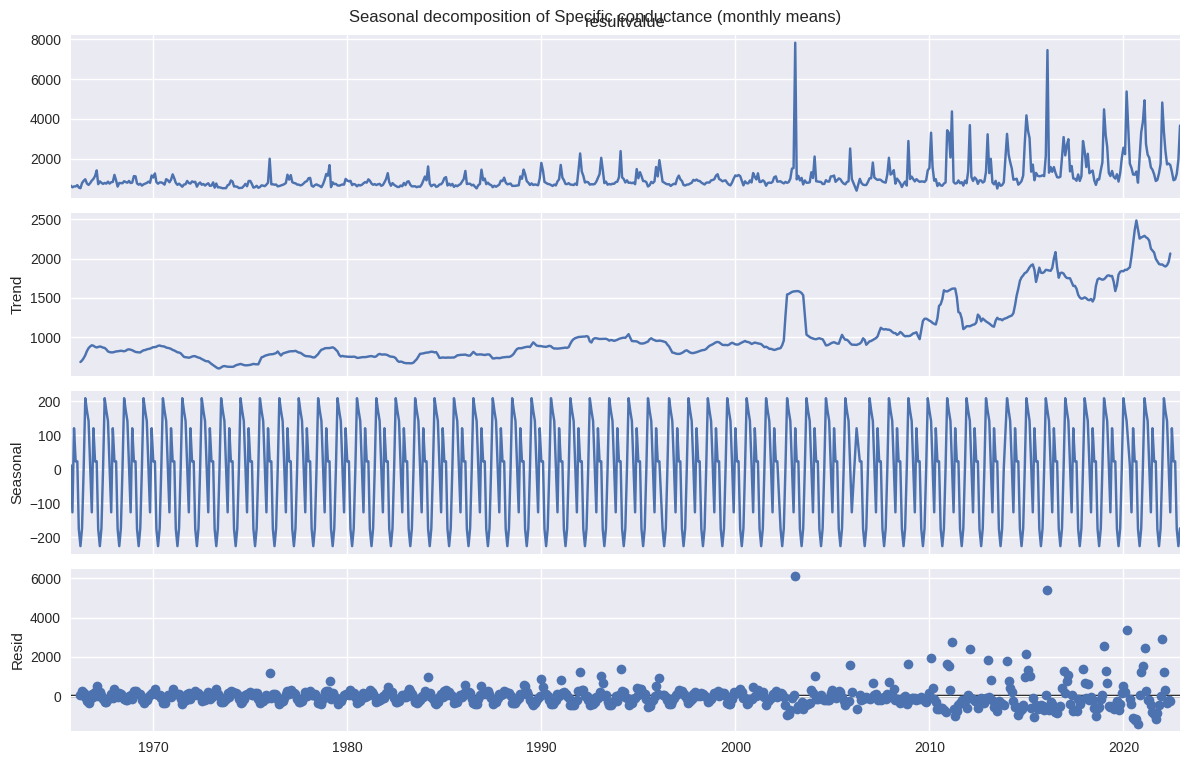

In [14]:
# ------------------------------------------------------------
# Seasonal decomposition of a key parameter (trend vs seasonality)
# ------------------------------------------------------------

!pip install statsmodels --quiet

import statsmodels.api as sm
import matplotlib.pyplot as plt

# Choose a parameter (same as before, or change)
param_for_decomp = "Specific conductance"
print("Parameter for seasonal decomposition:", param_for_decomp)

# Filter to that parameter and valid datetime
df_dec = df[df[char_col] == param_for_decomp].copy()
df_dec = df_dec.dropna(subset=["activity_datetime"])

# Aggregate to monthly mean (same idea as anomaly cell)
df_dec["month_date"] = df_dec["activity_datetime"].dt.to_period("M").dt.to_timestamp()

monthly_ts = (
    df_dec
    .groupby("month_date")[value_col]
    .mean()
    .sort_index()
)

print("Number of monthly points:", len(monthly_ts))

# Drop leading NaNs if any
monthly_ts = monthly_ts.dropna()

# Run additive seasonal decomposition (monthly frequency)
decomp = sm.tsa.seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Seasonal decomposition of {param_for_decomp} (monthly means)", y=0.95)
plt.tight_layout()
plt.show()


Parameter for trend analysis: Specific conductance
Yearly points: 58


,resultvalue
year,
1965,602.696970
1966,778.665354
1967,843.527851
1968,825.037647
1969,847.517900



Trend results:
  Slope per year: 15.8392 (units per year)
  Slope per decade: 158.3924 (units per decade)
  R-squared: 0.538

Model summary (truncated):
['                            OLS Regression Results                            ', '==============================================================================', 'Dep. Variable:                      y   R-squared:                       0.538', 'Model:                            OLS   Adj. R-squared:                  0.530', 'Method:                 Least Squares   F-statistic:                     65.23', 'Date:                Sat, 29 Nov 2025   Prob (F-statistic):           5.78e-11', 'Time:                        08:22:25   Log-Likelihood:                -401.53', 'No. Observations:                  58   AIC:                             807.1', 'Df Residuals:                      56   BIC:                             811.2', 'Df Model:                           1                                         ', 'Covariance Type:        

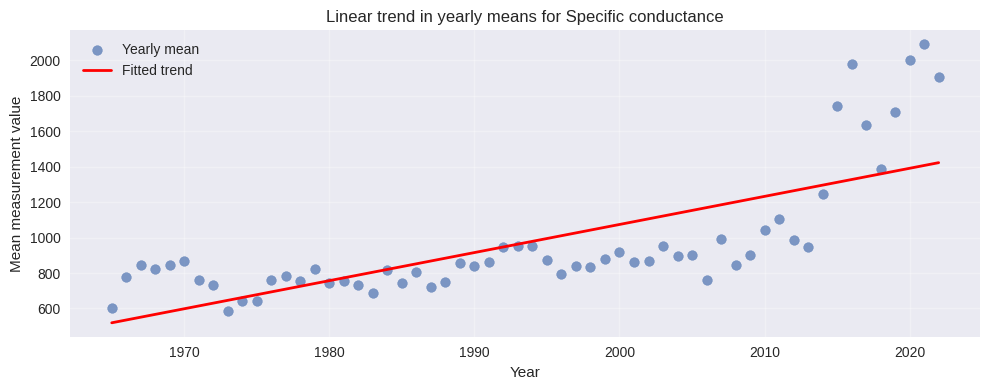

In [15]:
# ------------------------------------------------------------
# Linear trend analysis (OLS) for a key parameter
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

param_for_trend = "Specific conductance"   # change if you want another one
print("Parameter for trend analysis:", param_for_trend)

# 1. Filter to that parameter and valid datetime
df_trend = df[df[char_col] == param_for_trend].copy()
df_trend = df_trend.dropna(subset=["activity_datetime"])

# 2. Aggregate to yearly mean
yearly_series = (
    df_trend
    .groupby("year")[value_col]
    .mean()
    .sort_index()
)

print("Yearly points:", len(yearly_series))
display(yearly_series.head())

# Drop any missing values
yearly_series = yearly_series.dropna()

years = yearly_series.index.values.astype(float)
values = yearly_series.values.astype(float)

# 3. Fit a simple linear regression: value ~ year
X = sm.add_constant(years)   # adds intercept term
model = sm.OLS(values, X).fit()

slope = model.params[1]
intercept = model.params[0]
r2 = model.rsquared

print("\nTrend results:")
print(f"  Slope per year: {slope:.4f} (units per year)")
print(f"  Slope per decade: {slope * 10:.4f} (units per decade)")
print(f"  R-squared: {r2:.3f}")

print("\nModel summary (truncated):")
print(model.summary().as_text().split("\n")[0:12])  # show only first 12 lines

# 4. Build fitted line
year_grid = np.linspace(years.min(), years.max(), 200)
X_grid = sm.add_constant(year_grid)
y_pred = model.predict(X_grid)

# 5. Plot: yearly means + fitted trend line
fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(years, values, label="Yearly mean", alpha=0.7)
ax.plot(year_grid, y_pred, color="red", label="Fitted trend", linewidth=2)

ax.set_title(f"Linear trend in yearly means for {param_for_trend}")
ax.set_xlabel("Year")
ax.set_ylabel("Mean measurement value")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [16]:
# ------------------------------------------------------------
# Interactive folium map of monitoring locations
# ------------------------------------------------------------

!pip install folium --quiet

import folium
from folium import Choropleth, CircleMarker, Marker

param_for_map = "Specific conductance"   # you can change this

print("Building map for parameter:", param_for_map)

# Columns
loc_id_col   = get_col(df, "MonitoringLocationID")
lat_col      = get_col(df, "MonitoringLocationLatitude")
lon_col      = get_col(df, "MonitoringLocationLongitude")

# Filter rows for this parameter only
df_map = df[df[char_col] == param_for_map].copy()
df_map = df_map.dropna(subset=[lat_col, lon_col, value_col])

# Aggregate: one row per site
site_summary = (
    df_map
    .groupby(loc_id_col)
    .agg(
        mean_val   = (value_col, "mean"),
        median_val = (value_col, "median"),
        n_samples  = (value_col, "count"),
        lat        = (lat_col, "first"),
        lon        = (lon_col, "first"),
    )
    .reset_index()
)

# Center of Toronto for map initialization
toronto_center = [43.6532, -79.3832]

m = folium.Map(location=toronto_center, zoom_start=10, tiles="OpenStreetMap")

# Normalize size for markers
max_samples = site_summary["n_samples"].max()

for _, row in site_summary.iterrows():
    popup_text = (
        f"<b>Site:</b> {row[loc_id_col]}<br>"
        f"<b>Mean:</b> {row['mean_val']:.2f}<br>"
        f"<b>Median:</b> {row['median_val']:.2f}<br>"
        f"<b>Samples:</b> {row['n_samples']}"
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5 + 10 * (row["n_samples"] / max_samples),  # marker size
        color=None,
        fill=True,
        fill_color="blue",
        fill_opacity=0.6,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(m)

m


Building map for parameter: Specific conductance


In [18]:
# ------------------------------------------------------------
# Map 2: monitoring locations colored by mean value (with legend)
# ------------------------------------------------------------

import folium
from branca.colormap import linear

param_for_map = "Specific conductance"
print("Parameter for color-scaled map:", param_for_map)

# If site_summary doesn't exist, rebuild it
try:
    site_summary
except NameError:
    loc_id_col   = get_col(df, "MonitoringLocationID")
    lat_col      = get_col(df, "MonitoringLocationLatitude")
    lon_col      = get_col(df, "MonitoringLocationLongitude")

    df_map = df[df[char_col] == param_for_map].copy()
    df_map = df_map.dropna(subset=[lat_col, lon_col, value_col])

    site_summary = (
        df_map
        .groupby(loc_id_col)
        .agg(
            mean_val   = (value_col, "mean"),
            median_val = (value_col, "median"),
            n_samples  = (value_col, "count"),
            lat        = (lat_col, "first"),
            lon        = (lon_col, "first"),
        )
        .reset_index()
    )

# Color scale based on mean value
vmin = site_summary["mean_val"].min()
vmax = site_summary["mean_val"].max()

# FIXED HERE → use YlOrRd_09 (always available)
colormap = linear.YlOrRd_09.scale(vmin, vmax)
colormap.caption = f"Mean {param_for_map}"

# Create map
toronto_center = [43.6532, -79.3832]
m2 = folium.Map(location=toronto_center, zoom_start=10, tiles="CartoDB positron")

for _, row in site_summary.iterrows():
    popup_text = (
        f"<b>Site:</b> {row[loc_id_col]}<br>"
        f"<b>Mean:</b> {row['mean_val']:.2f}<br>"
        f"<b>Median:</b> {row['median_val']:.2f}<br>"
        f"<b>Samples:</b> {row['n_samples']}"
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=None,
        fill=True,
        fill_color=colormap(row["mean_val"]),
        fill_opacity=0.8,
        popup=folium.Popup(popup_text, max_width=300),
    ).add_to(m2)

colormap.add_to(m2)

m2


Parameter for color-scaled map: Specific conductance


In [19]:
# ------------------------------------------------------------
# Map 3: Heatmap of parameter intensity / sampling
# ------------------------------------------------------------

from folium.plugins import HeatMap
import numpy as np

param_for_heatmap = "Specific conductance"   # change if you want
print("Parameter for heatmap:", param_for_heatmap)

loc_id_col   = get_col(df, "MonitoringLocationID")
lat_col      = get_col(df, "MonitoringLocationLatitude")
lon_col      = get_col(df, "MonitoringLocationLongitude")

# Filter to this parameter and valid coords
df_heat = df[df[char_col] == param_for_heatmap].copy()
df_heat = df_heat.dropna(subset=[lat_col, lon_col, value_col])

print("Rows available for heatmap:", len(df_heat))

# Optionally cap extreme values so a few outliers don't dominate
q95 = df_heat[value_col].quantile(0.95)
weights = np.clip(df_heat[value_col], 0, q95)

# Normalize weights to 0–1
weights = weights / weights.max()

heat_data = list(zip(df_heat[lat_col], df_heat[lon_col], weights))

# Base map
toronto_center = [43.6532, -79.3832]
m3 = folium.Map(location=toronto_center, zoom_start=10, tiles="CartoDB dark_matter")

HeatMap(
    heat_data,
    radius=15,       # how far each point spreads
    blur=20,
    max_zoom=13,
).add_to(m3)

m3


Parameter for heatmap: Specific conductance
Rows available for heatmap: 34337
